# 과제: Fashion-MNIST 분류기 만들기

> **제출 기한**: 다음 수업 전까지  
> **제출 방법**: 이 노트북을 실행한 결과(출력 포함)를 저장하여 제출

---

## 과제 목표

지금까지 배운 PyTorch 학습 파이프라인을 실제 이미지 데이터에 적용합니다.

- `DataLoader` 로 미니배치 학습
- MLP 모델 설계 및 학습
- Train/Test Loss 시각화
- 결과 분석

---

## 데이터 소개: Fashion-MNIST

손글씨 숫자(MNIST) 대신 **의류/패션 아이템** 10종을 분류합니다.

| 레이블 | 클래스 |
|--------|--------|
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |

- 이미지 크기: 28×28 픽셀, 흑백
- 학습 데이터: 60,000장 / 테스트 데이터: 10,000장


---
## Step 1. 환경 준비 (코드 제공 — 수정 불필요)


In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

# 실험 결과의 재현성을 위해 무작위 난수 시드를 42로 고정
torch.manual_seed(42)

# Class names for visualization
CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'GPU' if torch.cuda.is_available() else 'CPU'}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


PyTorch version: 2.10.0+cu128
Device: GPU


---
## Step 2. 데이터 로드 (코드 제공 — 수정 불필요)

- 픽셀값은 0 ~ 255 → `ToTensor()`로 0 ~ 1 사이로 정규화됩니다.
- `Normalize((0.5,), (0.5,))` 로 -1 ~ 1 범위로 추가 정규화합니다.


In [2]:
# Data loading — provided
# 데이터 전처리 파이프라인 구성
transform = transforms.Compose([
    transforms.ToTensor(),
    # 평균(mean) 0.5, 표준편차(std) 0.5를 적용하여 픽셀 값을 -1.0 ~ 1.0 사이로 정규화 (Zero-centering)
    # 이는 역전파 과정에서 기울기가 한쪽으로 치우치는 것을 방지하고 모델의 학습 속도를 높여줌
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True,  download=True, transform=transform
)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

# 데이터셋을 지정된 배치 크기(64)로 나누어 모델에 공급해줄 DataLoader 생성
# 훈련 데이터는 에폭마다 섞어주어(shuffle=True) 모델이 데이터 순서를 외우는 과적합을 방지
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
# 평가용 데이터는 순서가 학습에 영향을 주지 않으므로 섞지 않음
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f"Train: {len(train_dataset):,} samples, {len(train_loader)} batches")
print(f"Test:  {len(test_dataset):,} samples, {len(test_loader)} batches")

# Check one batch shape
images, labels = next(iter(train_loader))
print(f"\nBatch shape: {images.shape}")   # (64, 1, 28, 28)
print(f"Label shape: {labels.shape}")      # (64,)


100%|██████████| 26.4M/26.4M [00:02<00:00, 13.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 208kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.88MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.2MB/s]

Train: 60,000 samples, 938 batches
Test:  10,000 samples, 157 batches

Batch shape: torch.Size([64, 1, 28, 28])
Label shape: torch.Size([64])


---
## Step 3. 데이터 시각화 (코드 제공 — 수정 불필요)


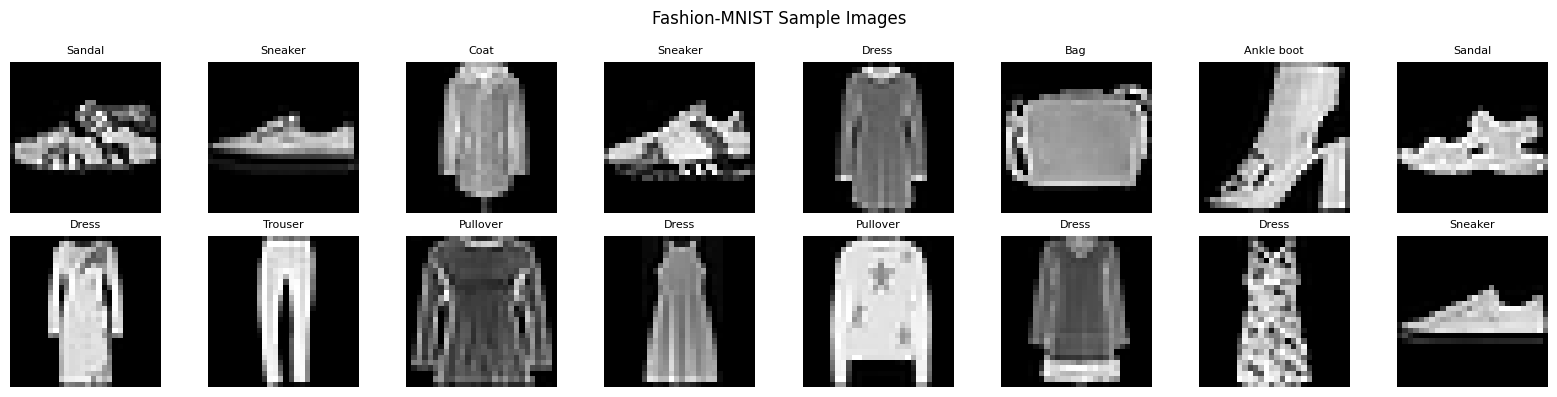

In [3]:
# Visualize sample images — provided
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flatten()):
    img = images[i].squeeze().numpy()
    ax.imshow(img, cmap='gray')
    ax.set_title(CLASS_NAMES[labels[i]], fontsize=8)
    ax.axis('off')
plt.suptitle("Fashion-MNIST Sample Images", fontsize=12)
plt.tight_layout(); plt.show()


---
## Step 4. 모델 설계 ✏️ 직접 구현

MLP 모델을 설계하세요.

**힌트**:
- 입력: 28×28 = **784** 차원 (이미지를 1D로 펼쳐야 합니다)
- 출력: **10** 클래스
- 은닉층 구조는 자유롭게 설계하세요
- 다중분류이므로 출력층 활성화 함수는 **Softmax가 아닌 Linear** 그대로 둡니다  
  (`nn.CrossEntropyLoss`가 내부적으로 Softmax를 포함합니다)

```
입력 (784) → 은닉층 → ... → 출력 (10)
```


In [4]:
class FashionMLP(nn.Module):
    def __init__(self):
        super().__init__()
        # 입력층: 28x28 해상도의 이미지를 1D로 펼친 784개의 특징을 입력으로 받음
        # 은닉층: 데이터의 패턴을 충분히 학습할 수 있도록 256개의 뉴런을 가진 선형 계층 구성
        self.fc1 = nn.Linear(784, 256)
        # 은닉층의 출력에 활성화 함수 적용시켜 비선형성 도입
        self.relu = nn.ReLU()
        # 출력층: 256개의 추상화된 특징을 입력받아, 최종 10개의 의류 클래스에 대한 로짓(Logit) 출력
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        # 1. Flattening: 배치 크기(x.size(0))는 유지하고, 나머지 차원을 하나로 평탄화
        # 차원 변화: (Batch, 1, 28, 28) -> (Batch, 784)
        x = x.view(x.size(0), -1) 
        
        # 2. 은닉층 통과
        # 차원 변화: (Batch, 784) -> (Batch, 256)
        x = self.fc1(x)
        
        # 3. 활성화 함수 통과 (차원 유지)
        x = self.relu(x)
        
        # 4. 출력층 통과
        # 차원 변화: (Batch, 256) -> (Batch, 10)
        x = self.fc2(x)
        return x

# Model test
# 생성한 모델 객체를 지정된 연산 장치(CPU or GPU)로 메모리 할당
model = FashionMLP().to(device)
print(model)

# 모델이 가진 전체 학습 가능한 파라미터(Weight + Bias) 개수 확인
# 연산: (784*256 + 256) + (256*10 + 10) = 203,530
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

# Shape test
x_test = torch.randn(4, 1, 28, 28).to(device)
out    = model(x_test)
print(f"Output shape: {out.shape}")   # Expected: torch.Size([4, 10])


FashionMLP(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)

Total parameters: 203,530
Output shape: torch.Size([4, 10])


---
## Step 5. 학습 루프 ✏️ 직접 구현

**힌트**:
- Loss function: `nn.CrossEntropyLoss()` (다중분류)
- Optimizer: `torch.optim.Adam`
- 배치 루프가 추가됩니다 — DataLoader에서 배치를 꺼내서 학습합니다

```python
for epoch in range(num_epochs):
    for images, labels in train_loader:   # ← 배치 루프 추가
        images, labels = images.to(device), labels.to(device)
        # 학습 5단계 ...
```


In [5]:
# 다중 클래스 분류를 위한 손실 함수 설정 (내부적으로 Softmax 연산을 포함)
criterion = nn.CrossEntropyLoss()   # ✏️ 다중분류 loss

# 학습 가능한 파라미터를 업데이트할 최적화 알고리즘으로 Adam 사용 (학습률 0.001)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)   # ✏️ optimizer (lr=0.001 권장)

num_epochs = 10
# 에폭마다의 손실과 정확도 추이를 기록할 리스트 초기화
train_losses, test_losses, test_accs = [], [], []

for epoch in range(num_epochs):
    # --- Train ---
    # 모델을 학습 모드로 설정 (학습 시에만 사용하는 레이어의 동작을 활성화)
    model.train()
    epoch_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        # ✏️ 학습 5단계를 구현하세요

        # 1. zero_grad: 이전 배치의 기울기(Gradient)가 누적되지 않도록 0으로 초기화
        optimizer.zero_grad()
        # 2. forward: 순전파(Forward pass): 모델에 이미지를 통과시켜 예측 로짓(Logit) 계산
        outputs = model(images)
        # 3. 손실 계산(Loss): 모델의 예측과 실제 정답 간의 오차 계산
        loss = criterion(outputs, labels)
        # 4. 역전파(Backward pass): 오차를 역방향으로 전파하여 각 가중치의 기울기 계산
        loss.backward()
        # 5. 가중치 업데이트(Step): 계산된 기울기를 바탕으로 최적화 알고리즘이 가중치 갱신
        optimizer.step()

        # 현재 배치의 손실값을 스칼라 형태로 추출하여 누적
        epoch_loss += loss.item()
    # 1에폭 동안의 평균 훈련 손실을 저장
    train_losses.append(epoch_loss / len(train_loader))

    # --- Evaluate ---
    # 모델을 평가 모드로 전환 (학습 시에만 사용하는 레이어의 동작을 정지시켜 추론 상태로 고정)
    model.eval()
    correct, total, te_loss = 0, 0, 0

    # 평가 과정에서는 기울기 계산을 하지 않으므로 메모리 사용량을 줄이고 연산 속도를 높임
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            te_loss  += criterion(outputs, labels).item()
            
            # 정확도 계산: outputs(로짓) 중 가장 값이 큰 인덱스가 최종 예측 클래스
            # torch.max는 (최대값, 인덱스)를 반환하므로 값은 버리고(_) 두 번째 인자(인덱스)만 사용
            _, predicted = torch.max(outputs, dim=1) 

            # 예측값과 실제 정답이 일치하는 개수를 합산하여 맞춘 횟수 누적
            correct += (predicted == labels).sum().item()
            # 평가한 전체 데이터의 개수 누적
            total   += labels.size(0)

    # 1에폭 동안의 평균 테스트 손실 및 정확도 저장
    test_losses.append(te_loss / len(test_loader))
    test_accs.append(correct / total)

    # 현재 에폭의 훈련 및 평가 결과 출력
    print(f"Epoch {epoch+1:2d}/{num_epochs} | "
          f"Train Loss: {train_losses[-1]:.4f} | "
          f"Test Loss: {test_losses[-1]:.4f} | "
          f"Test Acc: {test_accs[-1]*100:.1f}%")


Epoch  1/10 | Train Loss: 0.4890 | Test Loss: 0.4451 | Test Acc: 83.6%
Epoch  2/10 | Train Loss: 0.3741 | Test Loss: 0.3776 | Test Acc: 86.2%
Epoch  3/10 | Train Loss: 0.3336 | Test Loss: 0.3845 | Test Acc: 86.0%
Epoch  4/10 | Train Loss: 0.3112 | Test Loss: 0.3604 | Test Acc: 87.4%
Epoch  5/10 | Train Loss: 0.2921 | Test Loss: 0.3569 | Test Acc: 87.4%
Epoch  6/10 | Train Loss: 0.2754 | Test Loss: 0.3540 | Test Acc: 87.4%
Epoch  7/10 | Train Loss: 0.2602 | Test Loss: 0.3513 | Test Acc: 87.6%
Epoch  8/10 | Train Loss: 0.2509 | Test Loss: 0.3712 | Test Acc: 87.1%
Epoch  9/10 | Train Loss: 0.2387 | Test Loss: 0.3520 | Test Acc: 87.7%
Epoch 10/10 | Train Loss: 0.2303 | Test Loss: 0.3506 | Test Acc: 87.7%


---
## Step 6. 학습 곡선 시각화 (코드 제공 — 수정 불필요)


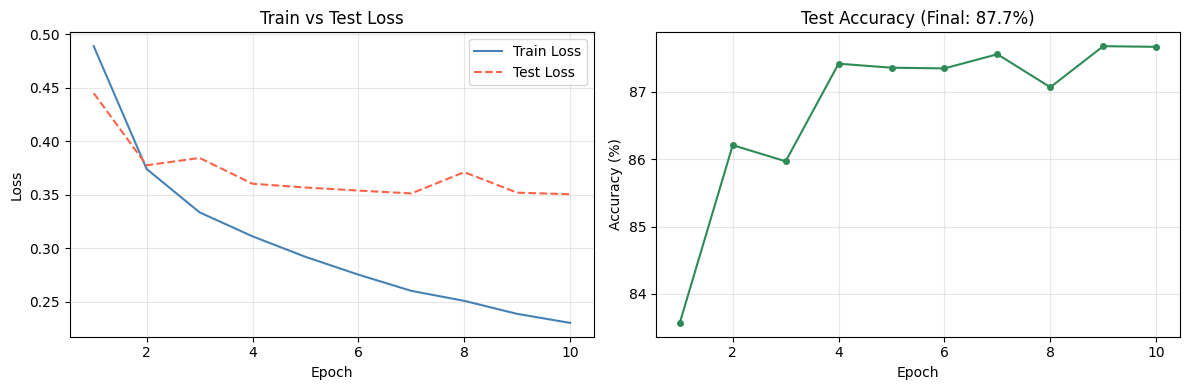

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


# [왼쪽 그래프] Train Loss와 Test Loss의 변화 추이 시각화
# Train Loss는 감소하지만 Test Loss가 멈추거나 상승한다면 과적합(Overfitting)을 의심할 수 있음
axes[0].plot(range(1, num_epochs+1), train_losses, label='Train Loss', color='steelblue')
axes[0].plot(range(1, num_epochs+1), test_losses,  label='Test Loss',  color='tomato', linestyle='--')
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Train vs Test Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# [오른쪽 그래프] Test Accuracy의 변화 추이 시각화
# 에폭이 지날수록 모델의 분류 성능이 어떻게 향상되는지 백분율(%)로 표기
axes[1].plot(range(1, num_epochs+1), [a*100 for a in test_accs], color='seagreen', marker='o', markersize=4)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title(f"Test Accuracy (Final: {test_accs[-1]*100:.1f}%)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


### Train Loss와 Test Loss의 정의

* **Train Loss (훈련 오차):**
  모델이 가중치를 업데이트하며 학습하는 과정에서 **'훈련 데이터(Train Data)'**를 상대로 계산한 오차입니다. 모델이 주어진 훈련 데이터의 패턴을 얼마나 잘 학습(기억)하고 있는지를 나타내는 지표입니다.

* **Test Loss (테스트 오차):**
  학습이 끝난(또는 진행 중인) 모델에 한 번도 본 적 없는 **'새로운 데이터(Test Data)'**를 입력하여 계산한 오차입니다. 모델이 단순히 훈련 데이터를 암기한 것을 넘어, 미지의 데이터에도 올바르게 예측을 수행할 수 있는지(일반화 성능, Generalization)를 평가하는 실질적인 성능 지표입니다.

### [학습 결과 분석] Train vs Test Loss 곡선

**1. 정상 학습 구간 (에폭 1~3)**
* Train Loss와 Test Loss가 동반 하락하며 모델이 데이터의 패턴을 정상적으로 학습함.

**2. 과적합 징후 발생 (에폭 4~10)**
* Train Loss는 0.23 수준까지 계속 감소하지만, Test Loss는 에폭 4 부근(약 0.36)부터 하락을 멈추고 정체됨.
* 이는 모델이 새로운 데이터에 대한 일반화 성능 개선을 멈추고, 훈련 데이터에 과적합(Overfitting)되기 시작했음을 의미함.


---
## Step 7. 예측 결과 시각화 (코드 제공 — 수정 불필요)

모델이 어떤 클래스를 헷갈려하는지 확인합니다.


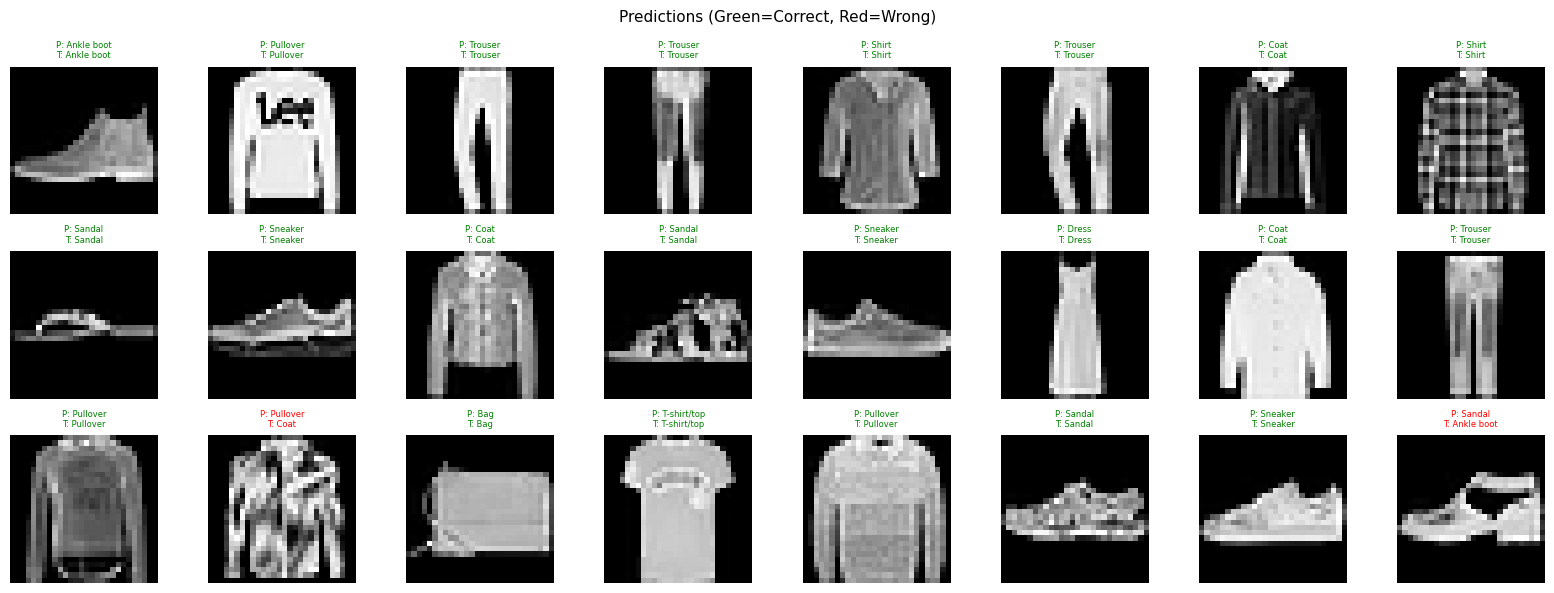

In [ ]:
# Visualize predictions — provided
model.eval()
images_vis, labels_vis = next(iter(test_loader))
images_vis = images_vis.to(device)

with torch.no_grad():
    outputs_vis = model(images_vis)
    _, preds_vis = torch.max(outputs_vis, 1)

fig, axes = plt.subplots(3, 8, figsize=(16, 6))
for i, ax in enumerate(axes.flatten()):
    img = images_vis[i].cpu().squeeze().numpy()
    pred  = CLASS_NAMES[preds_vis[i].item()]
    true  = CLASS_NAMES[labels_vis[i].item()]
    
    # 예측이 실제 정답과 일치하면 텍스트 색상을 초록색, 틀리면 빨간색으로 지정
    color = 'green' if pred == true else 'red'
    ax.imshow(img, cmap='gray')

    # 이미지 상단에 예측값(P)과 실제 정답(T)을 표시
    ax.set_title(f"P: {pred}\nT: {true}", fontsize=6, color=color)
    ax.axis('off')


plt.suptitle("Predictions (Green=Correct, Red=Wrong)", fontsize=11)
plt.tight_layout(); plt.show()


---
## Step 8. 틀린 샘플 분석 ✏️ 직접 구현

모델이 **가장 많이 헷갈리는 클래스 쌍**을 찾아보세요.

**힌트**: Confusion Matrix를 사용하면 됩니다.


In [9]:
%pip install seaborn

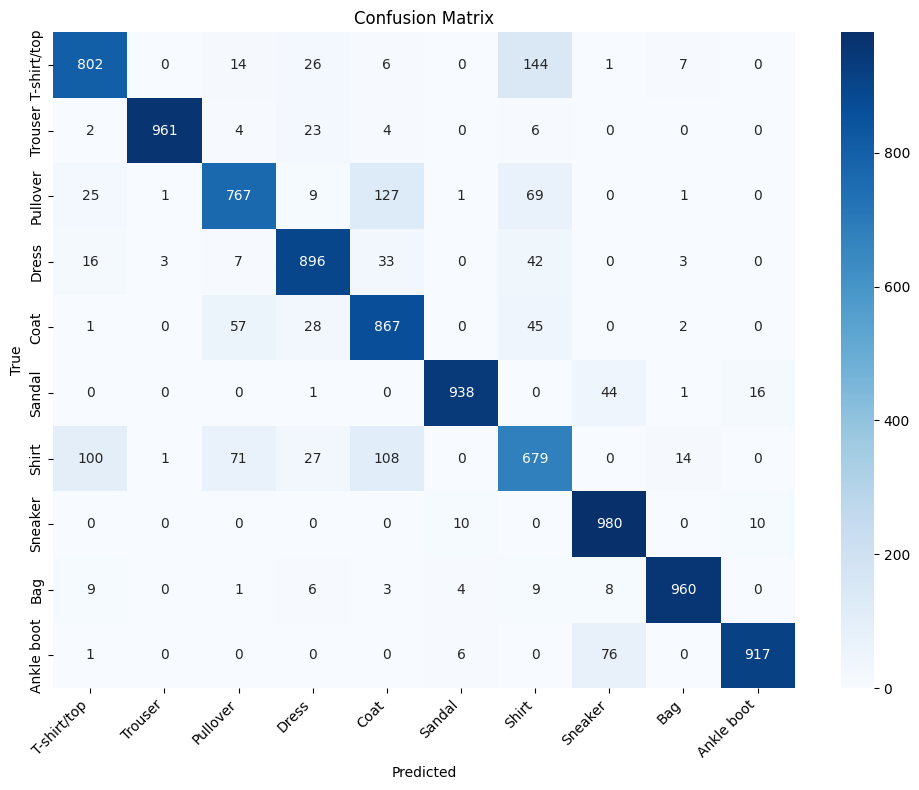


Most confused pairs:
  True: T-shirt/top     → Predicted: Shirt           (144번)
  True: Pullover        → Predicted: Coat            (127번)
  True: Shirt           → Predicted: Coat            (108번)


In [ ]:

from sklearn.metrics import confusion_matrix
import seaborn as sns

# 전체 테스트 데이터에 대한 모델의 예측값과 실제 정답을 한곳에 모으기 위한 리스트
all_preds, all_labels = [], []

# 평가 모드 설정 (학습 관련 레이어 비활성화)
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)

        # ✏️ 예측 클래스를 구해서 all_preds, all_labels에 추가하세요
        # 각 이미지에 대한 최종 예측 클래스 인덱스 추출
        _, predicted = torch.max(outputs, dim=1)
        all_preds.append(predicted.cpu())
        all_labels.append(labels.cpu())

# 리스트에 담긴 여러 개의 배치 텐서들을 하나의 1차원 텐서로 연결한 뒤, NumPy 배열로 최종 변환
all_preds  = torch.cat(all_preds).cpu().numpy()
all_labels = torch.cat(all_labels).cpu().numpy()

# Confusion matrix — provided
# ==========================================
# 혼동 행렬(Confusion Matrix) 시각화
# ==========================================
# 실제 정답과 예측값 배열을 바탕으로 10x10 크기의 혼동 행렬 계산
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion Matrix")
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

# Most confused pairs
print("\nMost confused pairs:")
# 원본 혼동 행렬을 복사
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

# 오답 빈도가 가장 높은 상위 3개의 쌍을 찾아 출력
for _ in range(3):
    # 2차원 배열에서 가장 큰 값의 위치(행, 열 인덱스)를 찾음
    idx = np.unravel_index(cm_no_diag.argmax(), cm_no_diag.shape)
    print(f"  True: {CLASS_NAMES[idx[0]]:15s} → Predicted: {CLASS_NAMES[idx[1]]:15s} ({cm_no_diag[idx]}번)")
    # 다음으로 큰 값을 찾기 위해 현재 찾은 최대값을 0으로 처리
    cm_no_diag[idx] = 0


---
## 제출 체크리스트

- [ ] Step 4: 모델 구조를 직접 설계했다
- [ ] Step 5: 학습 루프를 완성했다
- [ ] Step 5: 정확도 계산 코드를 완성했다
- [ ] Step 8: Confusion Matrix를 완성했다
- [ ] 모든 셀을 실행하여 출력 결과가 있다

---

## 보고 질문 (주관식, 간단히)

1. 최종 Test Accuracy는 몇 %였나요? 모델 구조(레이어 수, 뉴런 수)도 함께 적어주세요.

2. Confusion Matrix에서 가장 많이 헷갈리는 클래스 쌍은 무엇인가요? 왜 헷갈릴 것 같은지 한 문장으로 설명하세요.

3. 에폭을 늘리거나 모델 구조를 바꾸면 어떻게 될까요? 실험해보고 결과를 적어주세요. (선택)


---
1. 최종 test Accuracy: 87.7%, 모델 구조 - 2층 MLP [입력(784) -> Linear(256) -> ReLU ->  Linear(10) -> 출력
    - 입력층: 784개
    - 은닉층: 256개
    - 출력층: 10개

2. 티셔츠/상의(T-shirts/top)을 셔츠로 햇갈린 경우. (144번)
   - MNIST 데이터에선 낮은 해상도의 흑백 이미지이기 때문에 옷깃, 단추 등의 디테일이 뭉개져 전반적인 실루엣이 유사하게 나왔을것으로 추정됨.


3. 에폭을 늘리거나 모델 구조를 바꾸면 어떻게 될까요? 실험해보고 결과를 적어주세요. - 하단에 작성

In [9]:
# ==========================================
# [1단계] 3번 문제 실습용 새로운 모델 정의
# ==========================================

class DeepFashionMLP(nn.Module):
    def __init__(self):
        super().__init__()
        # 입력층(784) -> 은닉층1(512): 모델의 너비(Width)를 넓혀 복잡한 패턴 수용
        self.fc1 = nn.Linear(784, 512)
        
        # 은닉층1(512) -> 은닉층2(256): 층을 하나 더 쌓아 깊이(Depth)를 더함
        self.fc2 = nn.Linear(512, 256)
        
        # 은닉층2(256) -> 출력층(10): 최종 클래스 분류
        self.fc3 = nn.Linear(256, 10)
        
        # ReLU 활성화 함수
        self.relu = nn.ReLU()

    def forward(self, x):
        # 1. 평탄화: (Batch, 1, 28, 28) -> (Batch, 784)
        x = x.view(x.size(0), -1) 
        
        # 2. 첫 번째 선형 계층 + 활성화 함수
        x = self.fc1(x)
        x = self.relu(x)
        
        # 3. 두 번째 선형 계층 + 활성화 함수 (Deep하게 한 층 더!)
        x = self.fc2(x)
        x = self.relu(x)
        
        # 4. 출력층 (최종 로짓 반환)
        x = self.fc3(x)
        return x

# 모델 객체 생성 및 장치 할당
deep_model = DeepFashionMLP().to(device)

# 모델 구조 출력 및 파라미터 수 확인
print(deep_model)
print(f"\nTotal parameters: {sum(p.numel() for p in deep_model.parameters()):,}")

# Shape test
x_test = torch.randn(4, 1, 28, 28).to(device)
out    = deep_model(x_test)
print(f"Output shape: {out.shape}")   # Expected: torch.Size()

DeepFashionMLP(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=10, bias=True)
  (relu): ReLU()
)

Total parameters: 535,818
Output shape: torch.Size([4, 10])


In [10]:
# ==========================================
# [2단계] DeepFashionMLP 모델 학습 및 평가 진행
# ==========================================

# DeepFashionMLP 전용 최적화 알고리즘 설정 (학습률 0.001)
optimizer_deep = torch.optim.Adam(deep_model.parameters(), lr=0.001)

# 층이 깊어진 만큼 충분한 학습을 위해 에폭을 15로 설정
num_epochs_deep = 15 
deep_train_losses, deep_test_losses, deep_test_accs = [], [], []

print("\n=== DeepFashionMLP 모델 훈련 시작 ===")
for epoch in range(num_epochs_deep):
    # --- Train ---
    # 모델을 학습 모드로 설정
    deep_model.train()
    epoch_loss = 0
    
    for images, labels in train_loader:
        # 데이터와 레이블을 연산 장치로 이동
        images, labels = images.to(device), labels.to(device)
        
        # [학습 5단계 구현]
        # 1. zero_grad: 이전 배치의 기울기가 누적되지 않도록 초기화
        optimizer_deep.zero_grad()

        # 2. forward: 모델에 이미지를 통과시켜 예측값(Logit) 계산
        outputs = deep_model(images)
        
        # 3. loss: 예측값과 실제 정답 사이의 오차 계산
        loss = criterion(outputs, labels)

        # 4. backward: 오차를 바탕으로 기울기(Gradient) 계산
        loss.backward()

        # 5. step: 계산된 기울기를 가중치에 반영하여 업데이트
        optimizer_deep.step()
        # 현재 배치의 손실값을 누적
        epoch_loss += loss.item()

    # 1에폭 평균 훈련 손실 기록
    deep_train_losses.append(epoch_loss / len(train_loader))

    # --- Evaluate ---
    # 모델을 평가 모드로 전환
    deep_model.eval()
    correct, total, te_loss = 0, 0, 0

    # 평가 시에는 기울기 계산을 비활성화하여 자원 절약
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = deep_model(images)
            te_loss += criterion(outputs, labels).item()
            
            # 예측값 중 최대 인덱스 추출
            _, predicted = torch.max(outputs, dim=1) 

            # 정확도 계산을 위한 개수 합산
            correct += (predicted == labels).sum().item()
            total   += labels.size(0)

    # 1에폭 평균 테스트 손실 및 정확도 기록
    deep_test_losses.append(te_loss / len(test_loader))
    deep_test_accs.append(correct / total)

    # 현재 에폭의 훈련 및 평가 결과 출력
    print(f"Epoch {epoch+1:2d}/{num_epochs_deep} | "
          f"Train Loss: {deep_train_losses[-1]:.4f} | "
          f"Test Loss: {deep_test_losses[-1]:.4f} | "
          f"Test Acc: {deep_test_accs[-1]*100:.1f}%")


=== DeepFashionMLP 모델 훈련 시작 ===
Epoch  1/15 | Train Loss: 0.4824 | Test Loss: 0.4480 | Test Acc: 83.3%
Epoch  2/15 | Train Loss: 0.3646 | Test Loss: 0.3771 | Test Acc: 86.2%
Epoch  3/15 | Train Loss: 0.3276 | Test Loss: 0.3742 | Test Acc: 86.9%
Epoch  4/15 | Train Loss: 0.3005 | Test Loss: 0.3435 | Test Acc: 87.1%
Epoch  5/15 | Train Loss: 0.2794 | Test Loss: 0.3902 | Test Acc: 86.3%
Epoch  6/15 | Train Loss: 0.2606 | Test Loss: 0.3439 | Test Acc: 87.8%
Epoch  7/15 | Train Loss: 0.2462 | Test Loss: 0.3309 | Test Acc: 88.4%
Epoch  8/15 | Train Loss: 0.2334 | Test Loss: 0.3676 | Test Acc: 87.4%
Epoch  9/15 | Train Loss: 0.2192 | Test Loss: 0.3399 | Test Acc: 88.6%
Epoch 10/15 | Train Loss: 0.2081 | Test Loss: 0.3384 | Test Acc: 88.8%
Epoch 11/15 | Train Loss: 0.2008 | Test Loss: 0.3583 | Test Acc: 88.3%
Epoch 12/15 | Train Loss: 0.1873 | Test Loss: 0.3680 | Test Acc: 88.4%
Epoch 13/15 | Train Loss: 0.1797 | Test Loss: 0.3625 | Test Acc: 88.7%
Epoch 14/15 | Train Loss: 0.1707 | Test Loss

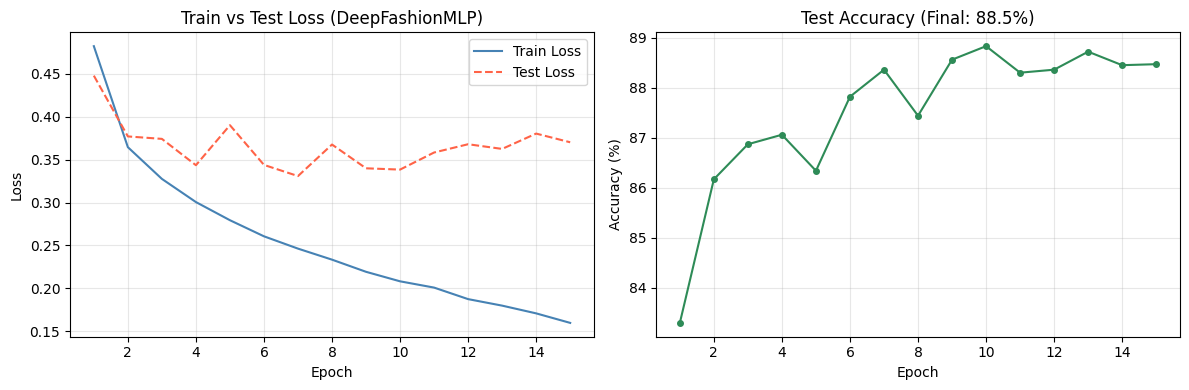

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# [왼쪽 그래프] Train Loss와 Test Loss의 변화 추이 시각화
axes[0].plot(range(1, num_epochs_deep+1), deep_train_losses, label='Train Loss', color='steelblue')
axes[0].plot(range(1, num_epochs_deep+1), deep_test_losses,  label='Test Loss',  color='tomato', linestyle='--')
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Train vs Test Loss (DeepFashionMLP)"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# [오른쪽 그래프] Test Accuracy의 변화 추이 시각화
axes[1].plot(range(1, num_epochs_deep+1), [a*100 for a in deep_test_accs], color='seagreen', marker='o', markersize=4)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title(f"Test Accuracy (Final: {deep_test_accs[-1]*100:.1f}%)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

---
 # ◎ 그래프 비교

 ## 초기 모델 그래프
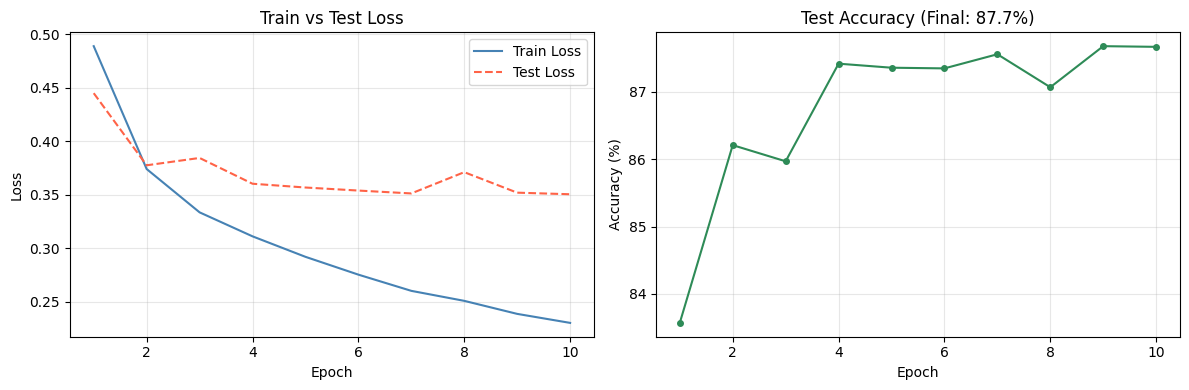

## 변경된 모델의 그래프
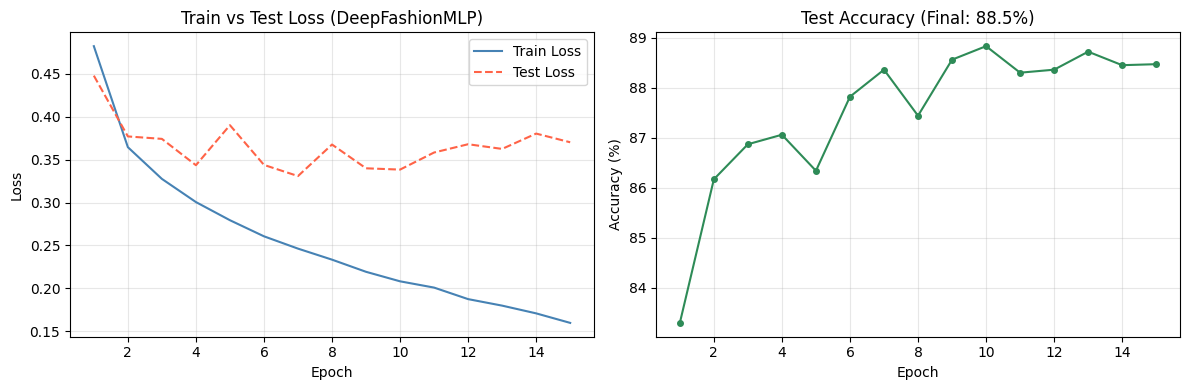

# 실험 보고서: 에폭 및 모델 구조 변경에 따른 성능 변화

---

## 1. 실험 개요

> **주제:** 에폭을 늘리거나 모델 구조를 바꾸면 어떻게 될까요?

기본 모델(`FashionMLP`)과 개선 모델(`DeepFashionMLP`)을 비교하여, **은닉층 추가**와 **에폭 증가**가 모델 성능에 어떤 영향을 미치는지 실험하였다.

---

## 2. 실험 설계

| 항목 | 기본 모델 (`FashionMLP`) | 개선 모델 (`DeepFashionMLP`) |
|:----:|:----------------------:|:---------------------------:|
| 모델 구조 | 784 → 256 → 10 | 784 → 512 → 256 → 10 |
| 은닉층 수 | 1개 | 2개 |
| 활성화 함수 | ReLU | ReLU |
| 옵티마이저 | Adam (lr=0.001) | Adam (lr=0.001) |
| 에폭 수 | 10 | 15 |
| **최종 Test Accuracy** | **87.7%** | **88.5%** |

---

## 3. 결과 분석

### 3-1. 정확도 향상

은닉층을 1개 추가하고 에폭을 15로 늘린 결과, 최종 테스트 정확도가 **87.7% → 88.5%** 로 약 **0.8%p** 향상되었다.  
층을 깊게 쌓을수록 모델이 더 복잡한 특징을 학습할 수 있기 때문으로 해석된다.

### 3-2. Train Loss의 더 깊은 하강

| 모델 | 최종 Train Loss (기준 에폭) |
|:----:|:--------------------------:|
| 기본 모델 | 약 0.23 (10 에폭) |
| 개선 모델 | 약 0.16 (15 에폭) |

파라미터 수가 늘어나면서 모델의 **표현력(capacity)** 이 커졌고, 그만큼 훈련 데이터에 대한 학습이 더 깊이 이루어졌다.

### 3-3. 과적합(Overfitting) 경향 심화

두 모델 모두 Train Loss는 지속적으로 하강하는 반면, **Test Loss는 중반 이후 수렴하거나 소폭 상승**하는 양상을 보인다.  
개선 모델에서 이 격차가 더 벌어지는 경향이 나타나, **모델이 깊어질수록 과적합 위험이 증가**함을 확인할 수 있다.

---

## 4. 결론

은닉층을 추가하고 에폭을 늘리면 모델의 **표현력이 높아져 성능이 향상**되지만,  
동시에 **과적합 위험과 학습 불안정성도 함께 증가**한다.

따라서 단순히 구조를 깊게 쌓는 것만으로는 한계가 있어 보임

---